<a href="https://colab.research.google.com/github/hazash97/jrVziAXIJvmftE4U/blob/main/1.0-hja-acme-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds);

spreadsheet = gc.open('ACME-HappinessSurvey2020')

# Raw Data Processing

In [5]:
def getData(tab_name):

  sheet = spreadsheet.worksheet(tab_name)

  values = sheet.get_all_values();

  headers = values[0];
  records = values[1:];
  data = pd.DataFrame.from_records(records, columns=headers);

  #de-stringify
  for col in data.columns:
      data[col] = pd.to_numeric(data[col]);

  return data


#Correlation Matrix

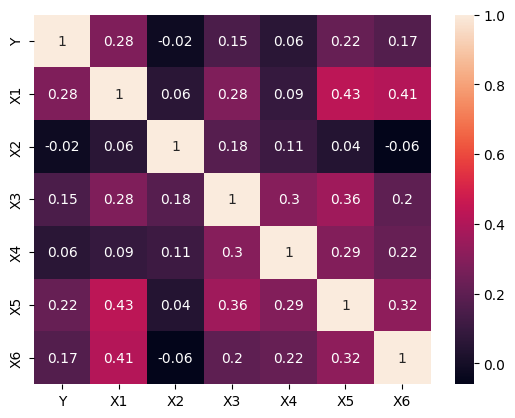

In [6]:
raw_data = getData('Raw Data')

correls = raw_data.corr().round(2)

import seaborn as sb
heatmap = sb.heatmap(correls,annot=True)

# Feature Selection

(Using new data sheet with X2 and X4 removed)

In [7]:
new_data = getData('Data')

y_data = np.array(new_data['Y'])
X_data = np.array(new_data.iloc[:,1:])

# Grid Search

  Logistic Regression

In [8]:
# define models and parameters
model = LogisticRegression()

solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]

# define grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data,y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.708129 using {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


SVM

In [9]:
# define model and parameters
model = svm.SVC()

kernel = ['poly', 'rbf', 'sigmoid']
C = [50, 10, 1.0, 0.1, 0.01]
gamma = ['scale']

# define grid search
grid = dict(kernel=kernel,C=C,gamma=gamma)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data,y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.707719 using {'C': 50, 'gamma': 'scale', 'kernel': 'sigmoid'}


Bagging Classifier

In [ ]:
# define models and parameters
model = BaggingClassifier()

n_estimators = [10, 100, 1000]

# define grid search
grid = dict(n_estimators=n_estimators)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data, y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Decision Tree

In [ ]:
# define models and parameters
model = DecisionTreeClassifier()

max_depth = np.arange(1,10)
max_features = [None, 'sqrt', 'log2']

path = model.cost_complexity_pruning_path(X_data,y_data)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

# define grid search
grid = dict(max_depth=max_depth,max_features=max_features,ccp_alpha=ccp_alphas)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data, y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Random Forest

In [ ]:
# define models and parameters
model = RandomForestClassifier()

n_estimators = [10, 100, 1000]
max_features = ['sqrt', 'log2']

# define grid search
grid = dict(n_estimators=n_estimators,max_features=max_features)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data, y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Naive Bayes

In [ ]:
# define models and parameters
model = GaussianNB()

var_smoothing = np.logspace(0,-9, num=10)

# define grid search
grid = dict(var_smoothing = var_smoothing)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data, y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

KNN

In [ ]:
# define models and parameters
model = KNeighborsClassifier()

n_neighbors = range(1, 21, 2)
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

# define grid search
grid = dict(n_neighbors=n_neighbors,weights=weights,metric=metric)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)

grid_search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='f1')
grid_result = grid_search.fit(X_data, y_data)

# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

In [ ]:
from sklearn.model_selection import train_test_split

model1 = LogisticRegression()
model2 = svm.SVC()

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

def getScore(model):
  model.fit(X_train,y_train)
  prediction = model.predict(X_test)
  return model.score(X_test,y_test)

print("model1: %f, model2: %f" % (getScore(model1), getScore(model2)))